# Ergebnisse – Experiment-Summary
- Pro Experiment & Datensatz eine Tabelle (mit `n_runs` bei Exp 1/2/4); Bar-Chart bei Exp 1/2/4, Exp 3 nur SHAP-Tabelle
- Quelle: alle MLflow-Runs aus `./mlruns`; fehlende/leere Experimente werden übersprungen

In [1]:
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Runs laden
- Nur vorhandene Experimente aus `./mlruns`; leere/fehlende werden übersprungen

In [2]:
mlflow.set_tracking_uri("file:./mlruns")

experiments = [f"{ds}_experiment_{i}" for ds in ["fake_jobs", "airbnb_paris"] for i in [1, 2, 3, 4]]

parts = []
for name in experiments:
    exp = mlflow.get_experiment_by_name(name)
    if exp is None:
        continue
    runs = mlflow.search_runs([exp.experiment_id])
    if len(runs) == 0:
        continue
    runs["experiment"] = name
    parts.append(runs)

df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
print(f"{len(df)} Runs aus {len(parts)} Experimenten geladen")

/home/debian/TFM_master_thesis/.venv/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


204 Runs aus 8 Experimenten geladen


## Aufbereiten
- Datensatz / Experiment-Nr. / Modellname ableiten; Metrik-Spalten vereinheitlichen

In [3]:
datasets = ["fake_jobs", "airbnb_paris"]

if len(df):
    df["exp_num"] = df["experiment"].str.split("_").str[-1].astype(int)
    df["dataset"] = df["experiment"].str.rsplit("_experiment_", n=1).str[0]
    df["model"] = df["tags.mlflow.runName"] if "tags.mlflow.runName" in df.columns else df["run_id"]
    df = df[df["model"] != "contexttab_fixed"]  # veralteten Run ausschließen
    df = df.rename(columns={"metrics.average_precision": "AP", "metrics.auc_roc": "AUROC", "metrics.runtime_s": "runtime_s"})
    for col in ["AP", "AUROC", "runtime_s"]:
        if col not in df.columns:
            df[col] = np.nan
    print("Datensätze:", df["dataset"].unique().tolist(), "| Experimente:", sorted(df["exp_num"].unique()))

Datensätze: ['fake_jobs', 'airbnb_paris'] | Experimente: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Experiment 1 – Unsupervised Outlier Detection
- TFMs (TabPFN unsup., AnoLLM, FoMo-OD) vs. PyOD-Baselines; AP & AUROC je Modell

=== Experiment 1 – fake_jobs ===


,AP,AUROC,runtime_s,n_runs
model,,,,
anollm,0.1015,0.6326,5782.5427,3
autoencoder,0.0924,0.6409,135.0691,3
iforest,0.0915,0.6125,2.2812,3
ecod,0.0759,0.6125,0.3393,3
fomo_od,0.0630,0.6040,0.2345,3
loda,0.0609,0.5108,0.5385,3
tabpfn_unsup,0.0585,0.5218,211.7583,3


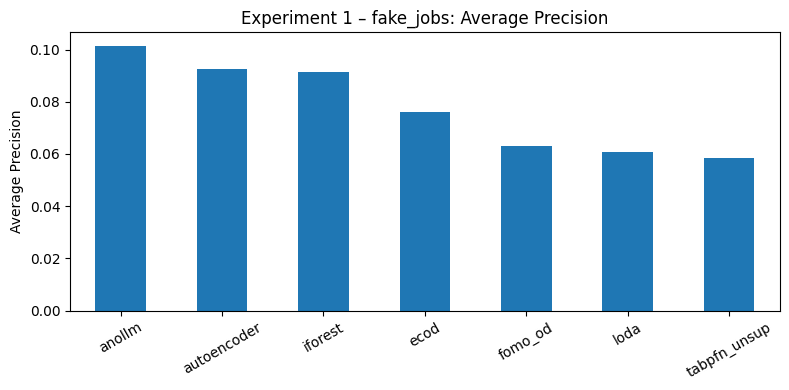

=== Experiment 1 – airbnb_paris ===


,AP,AUROC,runtime_s,n_runs
model,,,,
ecod,0.0945,0.7213,0.5643,3
iforest,0.0849,0.7060,2.1115,3
loda,0.0760,0.6298,0.5789,3
autoencoder,0.0635,0.6510,141.0601,3
tabpfn_unsup,0.0611,0.6453,869.6986,3
anollm,0.0495,0.5944,5692.6353,3
fomo_od,0.0426,0.5182,0.2387,3


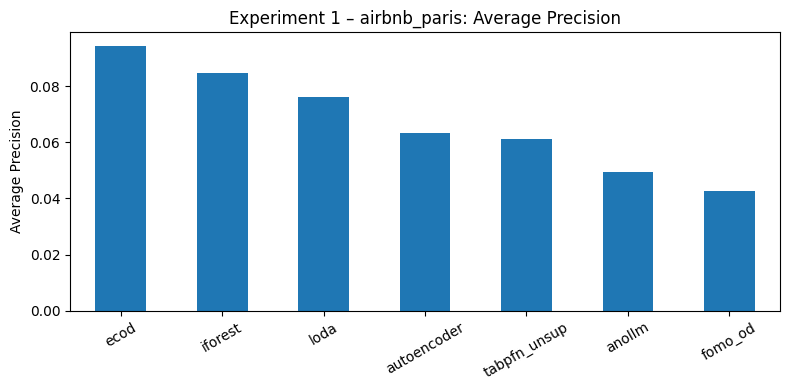

In [4]:
for ds in datasets:
    sub = df[(df["exp_num"] == 1) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-1-Runs")
        continue
    g = sub.groupby("model")
    tab = g[["AP", "AUROC", "runtime_s"]].mean()
    tab["n_runs"] = g.size()
    tab = tab.sort_values("AP", ascending=False).round(4)
    print(f"=== Experiment 1 – {ds} ===")
    display(tab)
    ax = tab["AP"].plot.bar(figsize=(8, 4), rot=30)
    ax.set_title(f"Experiment 1 – {ds}: Average Precision")
    ax.set_ylabel("Average Precision")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

## Experiment 2 – Enhanced Baseline-Modelle
- Baselines auf cleaned vs. semantisch vs. enhanced vs. enhanced+semantisch (AP je Detektor)
- Hinweis: enhanced ist semi-supervised (Label-Leakage), nicht direkt mit unsupervised vergleichbar

=== Experiment 2 – fake_jobs (AP & n_runs je Detektor × Repräsentation) ===


AP                                                  \
params.representation cleaned enhanced enhanced_pca30 enhanced_semantic_pca30   
params.detector                                                                 
autoencoder            0.0803   0.6078         0.6272                  0.1983   
ecod                   0.0759   0.1540         0.1100                  0.0825   
iforest                0.0876   0.1738         0.1496                  0.1109   
loda                   0.0601   0.1922         0.1237                  0.0448   

                                                      n_runs           \
params.representation semantic_pca100 semantic_pca30 cleaned enhanced   
params.detector                                                         
autoencoder                    0.0818         0.0945       3        3   
ecod                           0.0460         0.0587       3        3   
iforest                        0.0570         0.0869       3        3   
loda                           0.0452         0.0387       3        3   

                                                                              \
params.representation enhanced_pca30 enhanced_semantic_pca30 semantic_pca100   
params.detector                                                                
autoencoder                        3                       3               3   
ecod                               3                       3               3   
iforest                            3                       3               3   
loda                               3                       3               3   

                                      
params.representation semantic_pca30  
params.detector                       
autoencoder                        3  
ecod                               3  
iforest                            3  
loda                               3

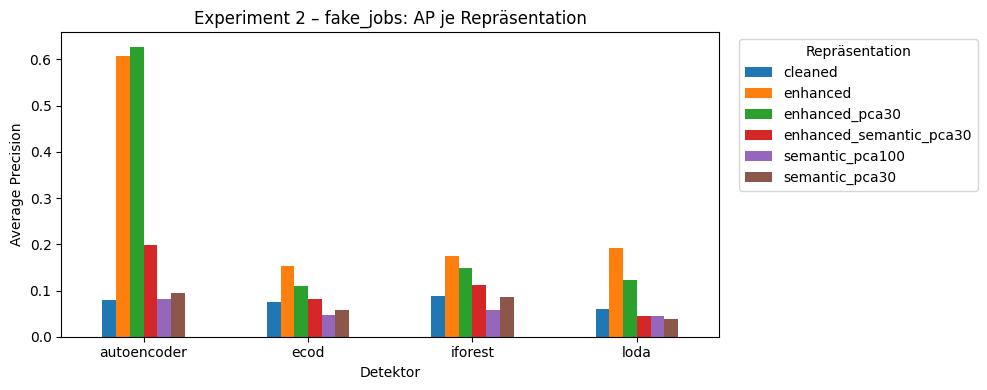

=== Experiment 2 – airbnb_paris (AP & n_runs je Detektor × Repräsentation) ===


AP                                                  \
params.representation cleaned enhanced enhanced_pca30 enhanced_semantic_pca30   
params.detector                                                                 
autoencoder            0.0714   0.3190         0.4692                  0.1850   
ecod                   0.1085   0.0688         0.2705                  0.1462   
iforest                0.0886   0.1423         0.2305                  0.1029   
loda                   0.0769   0.0822         0.1937                  0.0653   

                                                      n_runs           \
params.representation semantic_pca100 semantic_pca30 cleaned enhanced   
params.detector                                                         
autoencoder                    0.0512         0.0607       3        3   
ecod                           0.0677         0.0846       3        3   
iforest                        0.0698         0.0808       3        3   
loda                           0.0514         0.0684       3        3   

                                                                              \
params.representation enhanced_pca30 enhanced_semantic_pca30 semantic_pca100   
params.detector                                                                
autoencoder                        3                       3               3   
ecod                               3                       3               3   
iforest                            3                       3               3   
loda                               3                       3               3   

                                      
params.representation semantic_pca30  
params.detector                       
autoencoder                        3  
ecod                               3  
iforest                            3  
loda                               3

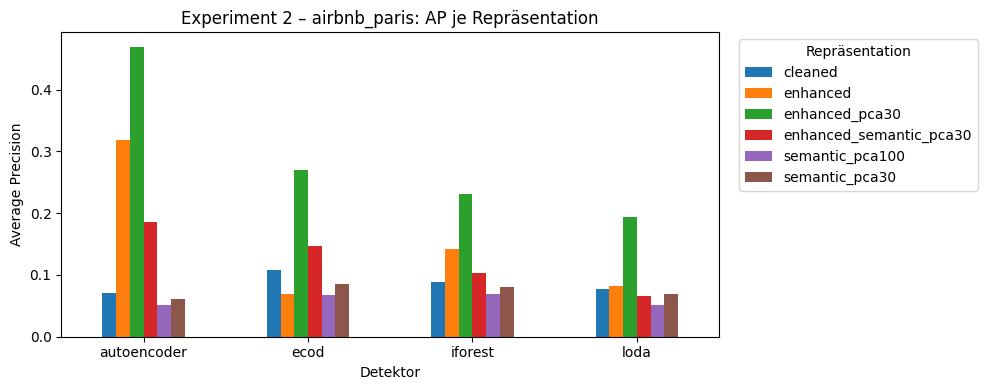

In [5]:
for ds in datasets:
    sub = df[(df["exp_num"] == 2) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-2-Runs")
        continue
    piv = sub.pivot_table(index="params.detector", columns="params.representation", values="AP", aggfunc=["mean", "size"]).round(4)
    piv = piv.rename(columns={"mean": "AP", "size": "n_runs"}, level=0)
    print(f"=== Experiment 2 – {ds} (AP & n_runs je Detektor × Repräsentation) ===")
    display(piv)
    ax = piv["AP"].plot.bar(figsize=(10, 4), rot=0)
    ax.set_title(f"Experiment 2 – {ds}: AP je Repräsentation")
    ax.set_ylabel("Average Precision")
    ax.set_xlabel("Detektor")
    ax.legend(title="Repräsentation", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Experiment 3 – Semantische Relevanz (SHAP)
- ConTextTab-SHAP: wichtigste Features je Datensatz (nur Tabelle)

In [6]:
for ds in datasets:
    sub = df[(df["exp_num"] == 3) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        continue
    rel_cols = [c for c in sub.columns if c.startswith("metrics.") and not c.endswith("_total") and sub[c].notna().any()]
    rel = sub.iloc[0][rel_cols].dropna().astype(float)
    rel.index = [c.replace("metrics.", "") for c in rel.index]
    top = rel.sort_values(ascending=False).head(20).round(4).to_frame("mean_abs_shap")
    top["type"] = ["text" if i.startswith("text_") else "numeric" for i in top.index]
    top.index = [i.replace("text_", "").replace("num_", "") for i in top.index]
    print(f"=== Experiment 3 – {ds}: Top 20 Features (Text + numerisch) ===")
    display(top)

=== Experiment 3 – fake_jobs: Top 20 Features (Text + numerisch) ===


,mean_abs_shap,type
company_profile,0.1373,text
has_company_logo,0.0547,numeric
title,0.0503,text
description,0.0354,text
has_questions,0.0310,numeric
requirements,0.0286,text
salary_avg,0.0265,numeric
country,0.0150,numeric
benefits,0.0136,text
industry,0.0116,numeric


=== Experiment 3 – airbnb_paris: Top 20 Features (Text + numerisch) ===


,mean_abs_shap,type
host_tenure_days,0.0352,numeric
name,0.0352,text
estimated_occupancy_l365d,0.0276,numeric
calculated_host_listings_count,0.0265,numeric
host_is_superhost,0.0216,numeric
calculated_host_listings_count_entire_homes,0.0180,numeric
description,0.0170,text
minimum_nights,0.0163,numeric
instant_bookable,0.0162,numeric
accommodates,0.0147,numeric


## Experiment 4 – TFMs zur binären Klassifikation
- ConTextTab vs. TabPFN-Klassifikation; AP & AUROC je Modell

=== Experiment 4 – fake_jobs ===


,AP,AUROC,runtime_s,n_runs
model,,,,
contexttab,0.9150,0.9649,2.4600,3
tabpfn_classification,0.8412,0.9453,2.1067,3


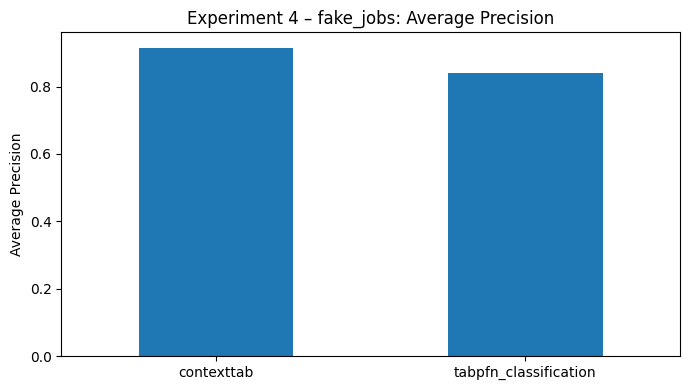

=== Experiment 4 – airbnb_paris ===


,AP,AUROC,runtime_s,n_runs
model,,,,
tabpfn_classification,0.6184,0.8553,2.1933,3
contexttab,0.5915,0.8754,1.6567,3


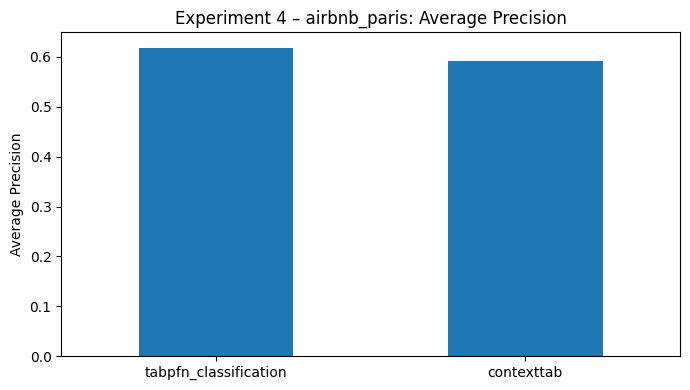

In [7]:
for ds in datasets:
    sub = df[(df["exp_num"] == 4) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-4-Runs")
        continue
    g = sub.groupby("model")
    tab = g[["AP", "AUROC", "runtime_s"]].mean()
    tab["n_runs"] = g.size()
    tab = tab.sort_values("AP", ascending=False).round(4)
    print(f"=== Experiment 4 – {ds} ===")
    display(tab)
    ax = tab["AP"].plot.bar(figsize=(7, 4), rot=0)
    ax.set_title(f"Experiment 4 – {ds}: Average Precision")
    ax.set_ylabel("Average Precision")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()